<a href="https://colab.research.google.com/github/natalatatis/Household-Income-Analysis/blob/main/MODELS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#HOUSEHOLD INCOME ANALYSIS

##Random Forest

In [77]:
# Imports
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, median_absolute_error, mean_squared_error

###Loading data

In [78]:
column_names = ['Age', 'Education_Level', 'Occupation', "Number_of_Dependents", "Location", "Work_Experience",
                "Marital_Status", "Employment_Status", "Household_Size","Homeownership_Status", "Type_of_Housing",
                "Gender", "Primary_Mode_of_Transportation", "Income"]

df = pd.read_csv("data.csv", names=column_names, na_values="?", skipinitialspace=True)
df = df.drop(index=0)

df

,Age,Education_Level,Occupation,Number_of_Dependents,Location,Work_Experience,Marital_Status,Employment_Status,Household_Size,Homeownership_Status,Type_of_Housing,Gender,Primary_Mode_of_Transportation,Income
1,56,Master's,Technology,5,Urban,21,Married,Full-time,7,Own,Apartment,Male,Public transit,72510
2,69,High School,Finance,0,Urban,4,Single,Full-time,7,Own,Apartment,Male,Biking,75462
3,46,Bachelor's,Technology,1,Urban,1,Single,Full-time,7,Own,Single-family home,Female,Car,71748
4,32,High School,Others,2,Urban,32,Married,Full-time,1,Own,Apartment,Female,Car,74520
5,60,Bachelor's,Finance,3,Urban,15,Married,Self-employed,4,Own,Townhouse,Male,Walking,640210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,58,High School,Others,0,Suburban,26,Divorced,Full-time,6,Own,Townhouse,Female,Car,74994
9997,23,Master's,Technology,3,Urban,16,Divorced,Full-time,1,Own,Single-family home,Female,Biking,72676
9998,41,Doctorate,Education,3,Urban,50,Single,Full-time,4,Own,Single-family home,Female,Public transit,2684820
9999,44,High School,Education,0,Urban,3,Married,Part-time,1,Own,Single-family home,Male,Biking,57955


###Clean numeric columns


In [79]:
numeric_cols = ["Age", "Number_of_Dependents", "Work_Experience", "Household_Size", "Income"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill missing values
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())


###Define features and target

In [80]:
# Clip extreme incomes
upper_limit = df["Income"].quantile(0.95)

df["Income_Clipped"] = np.clip(
    df["Income"],
    None,
    upper_limit
)

# New target
y = np.log1p(df["Income_Clipped"])

# Features
X = df.drop(["Income", "Income_Clipped"], axis=1)

###Split dataset

In [81]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

###Preprocessing

In [82]:
numeric_features = ["Age", "Number_of_Dependents", "Work_Experience", "Household_Size"]
categorical_features = [col for col in X.columns if col not in numeric_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

###Model pipeline

In [83]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=1200,
        max_depth=12,
        min_samples_split=20,
        min_samples_leaf=8,
        max_features=0.5,
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    ))
])

###Train

In [84]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age',
                                                   'Number_of_Dependents',
                                                   'Work_Experience',
                                                   'Household_Size']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Education_Level',
                                                   'Occupation', 'Location',
                                                   'Marital_Status',
                                                   'Employment_Status',
                                                   'Homeownership_Status',
                                                   'Type_of_Housing', 'Gender',
                                                   'Primary_Mode_of_Transportation'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=12, max_features=0.5,
                                       min_samples_leaf=8, min_samples_split=20,
                                       n_estimators=1200, n_jobs=-1,
                                       oob_score=True, random_state=42))])

In [85]:
print("OOB Score:", model.named_steps["regressor"].oob_score_)

OOB Score: 0.19294782589015425


###Predict (on log scale)

In [86]:
preds_log = model.predict(X_test)

###Evaluate (log scale)

In [87]:
r2_log = r2_score(y_test, preds_log)
print("R2 (log):", r2_log)

R2 (log): 0.19061884562743703


###Converting to real scale

In [88]:
y_pred = np.expm1(preds_log)
y_true = np.expm1(y_test)


###Evaluating on real scale

In [89]:
# MAE
mae = mean_absolute_error(y_true, y_pred)

# Median Absolute Error
med_ae = median_absolute_error(y_true, y_pred)

# RMSE
rmse = np.sqrt(
    mean_squared_error(y_true, y_pred)
)

print("\nReal-world metrics:")
print(f"MAE: ${mae:,.2f}")
print(f"Median AE: ${med_ae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")


Real-world metrics:
MAE: $663,430.19
Median AE: $109,562.14
RMSE: $1,501,266.59


---

##Pipeline XGBoost

In [90]:
#imports
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, median_absolute_error, mean_squared_error

from xgboost import XGBRegressor

###Load data

In [91]:
column_names = ['Age', 'Education_Level', 'Occupation', "Number_of_Dependents", "Location", "Work_Experience",
                "Marital_Status", "Employment_Status", "Household_Size","Homeownership_Status", "Type_of_Housing",
                "Gender", "Primary_Mode_of_Transportation", "Income"]

df = pd.read_csv("data.csv", names=column_names, na_values="?", skipinitialspace=True)
df = df.drop(index=0)


###Clean numeric columns

In [92]:
numeric_cols = ["Age", "Number_of_Dependents", "Work_Experience", "Household_Size", "Income"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill missing values
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

###Features and target

In [93]:
X = df.drop("Income", axis=1)
y = np.log1p(df["Income"])   # keep log


###Split dataset

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

###Preprocessing

In [95]:
numeric_features = ["Age", "Number_of_Dependents", "Work_Experience", "Household_Size"]
categorical_features = [col for col in X.columns if col not in numeric_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

###Model Pipeline

In [96]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

###Train

In [97]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age',
                                                   'Number_of_Dependents',
                                                   'Work_Experience',
                                                   'Household_Size']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Education_Level',
                                                   'Occupation', 'Location',
                                                   'Marital_Status',
                                                   'Employment_Status',
                                                   'Homeownership_Status',
                                                   'Type_of_Housing', 'Gender',
                                                   'Primary_Mode_of_Tr...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=5, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=-1,
                              num_parallel_tree=None, ...))])

###Predict (on log scale)

In [98]:
preds_log = model.predict(X_test)

###Evaluate (log scale)

In [99]:
r2_log = r2_score(y_test, preds_log)
print("R2 (log):", r2_log)


R2 (log): 0.0815544657308741


###Convert to real scale

In [100]:
y_pred = np.expm1(preds_log)
y_true = np.expm1(y_test)

###Evaluate on real scale

In [101]:
# MAE
mae = mean_absolute_error(y_true, y_pred)

# Median Absolute Error
med_ae = median_absolute_error(y_true, y_pred)

# RMSE
rmse = np.sqrt(
    mean_squared_error(y_true, y_pred)
)

print("\nReal-world metrics:")
print(f"MAE: ${mae:,.2f}")
print(f"Median AE: ${med_ae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")


Real-world metrics:
MAE: $774,077.87
Median AE: $114,830.40
RMSE: $1,862,729.23


---

##Gradient Boosting (sklearn)

In [102]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, median_absolute_error, mean_squared_error

from sklearn.ensemble import GradientBoostingRegressor

###Load data

In [103]:
column_names = ['Age', 'Education_Level', 'Occupation', "Number_of_Dependents", "Location", "Work_Experience",
                "Marital_Status", "Employment_Status", "Household_Size","Homeownership_Status", "Type_of_Housing",
                "Gender", "Primary_Mode_of_Transportation", "Income"]

df = pd.read_csv("data.csv", names=column_names, na_values="?", skipinitialspace=True)
df = df.drop(index=0)

###Clean numeric columns

In [104]:
numeric_cols = ["Age", "Number_of_Dependents", "Work_Experience", "Household_Size", "Income"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill missing values
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())


###Features and target

In [105]:
X = df.drop("Income", axis=1)
y = np.log1p(df["Income"])

###Split dataset

In [106]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

###Preprocessing

In [107]:
numeric_features = ["Age", "Number_of_Dependents", "Work_Experience", "Household_Size"]
categorical_features = [col for col in X.columns if col not in numeric_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

###Model

In [108]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

###Train model

In [109]:
model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age',
                                                   'Number_of_Dependents',
                                                   'Work_Experience',
                                                   'Household_Size']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Education_Level',
                                                   'Occupation', 'Location',
                                                   'Marital_Status',
                                                   'Employment_Status',
                                                   'Homeownership_Status',
                                                   'Type_of_Housing', 'Gender',
                                                   'Primary_Mode_of_Transportation'])])),
                ('regressor',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=500,
                                           random_state=42))])

###Predict (on log scale)

In [110]:
preds_log = model.predict(X_test)

###Evaluate

In [111]:
r2_log = r2_score(y_test, preds_log)
print("R2 (log):", r2_log)


R2 (log): 0.06908958902028883


###Convert to "real-world" scale

In [112]:
y_pred = np.expm1(preds_log)
y_true = np.expm1(y_test)

###Evaluate

In [113]:
# MAE
mae = mean_absolute_error(y_true, y_pred)

# Median Absolute Error
med_ae = median_absolute_error(y_true, y_pred)

# RMSE
rmse = np.sqrt(
    mean_squared_error(y_true, y_pred)
)

print("\nReal-world metrics:")
print(f"MAE: ${mae:,.2f}")
print(f"Median AE: ${med_ae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")


Real-world metrics:
MAE: $776,129.89
Median AE: $120,792.98
RMSE: $1,874,087.46


##CHECKING STUFF ABOUT DATASET

Income                                           1.000000
Homeownership_Status_Rent                        0.062561
Location_Urban                                  -0.052968
Employment_Status_Part-time                      0.031925
Location_Suburban                                0.028269
Work_Experience                                 -0.027541
Occupation_Finance                              -0.025784
Education_Level_Doctorate                       -0.023726
Education_Level_High School                      0.018451
Type_of_Housing_Townhouse                       -0.018225
Marital_Status_Married                           0.012652
Primary_Mode_of_Transportation_Car              -0.012069
Employment_Status_Self-employed                 -0.011982
Number_of_Dependents                             0.011413
Household_Size                                  -0.011356
Type_of_Housing_Single-family home              -0.010527
Marital_Status_Single                           -0.009057
Age           

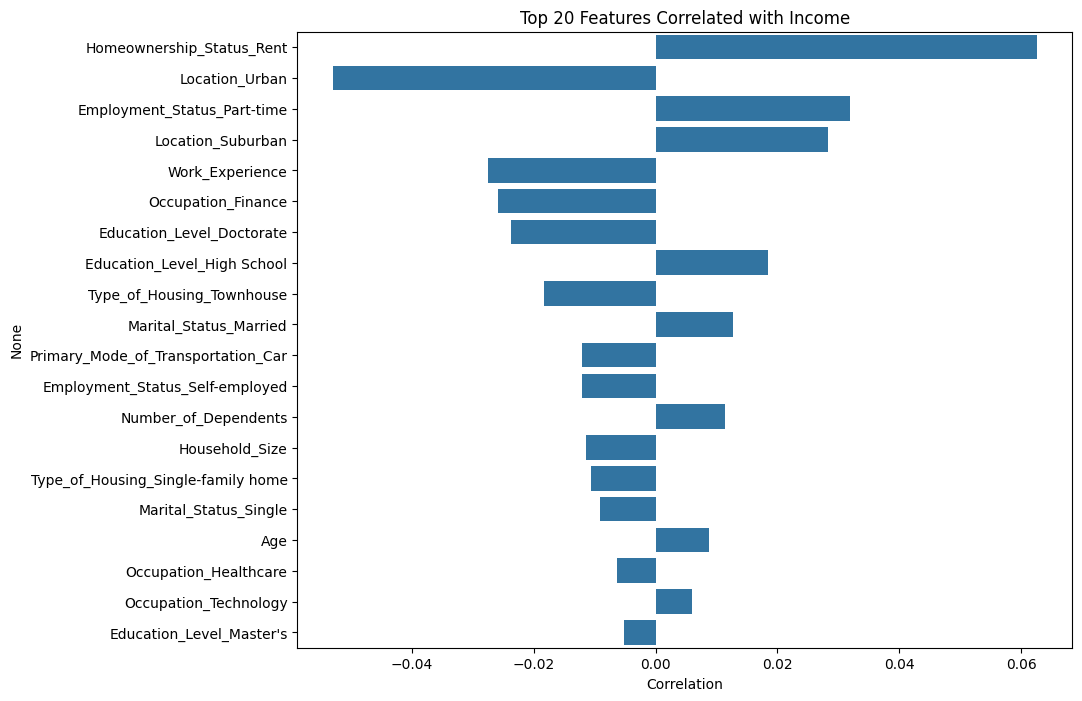

In [114]:
import pandas as pd
import numpy as np

# -----------------------------
# Create a copy
# -----------------------------
corr_df = df.copy()

# -----------------------------
# Convert categoricals using one-hot encoding
# -----------------------------
corr_df = pd.get_dummies(corr_df, drop_first=True)

# -----------------------------
# Compute correlations
# -----------------------------
corr_matrix = corr_df.corr(numeric_only=True)

# -----------------------------
# Correlation with Income
# -----------------------------
income_corr = corr_matrix["Income"].sort_values(
    ascending=False,
    key=lambda x: abs(x)   # sort by absolute value
)

# -----------------------------
# Print ALL correlations
# -----------------------------
print(income_corr)

# -----------------------------
# Top 20 strongest correlations
# -----------------------------
top_corr = income_corr.drop("Income").head(20)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title("Top 20 Features Correlated with Income")
plt.xlabel("Correlation")

plt.show()

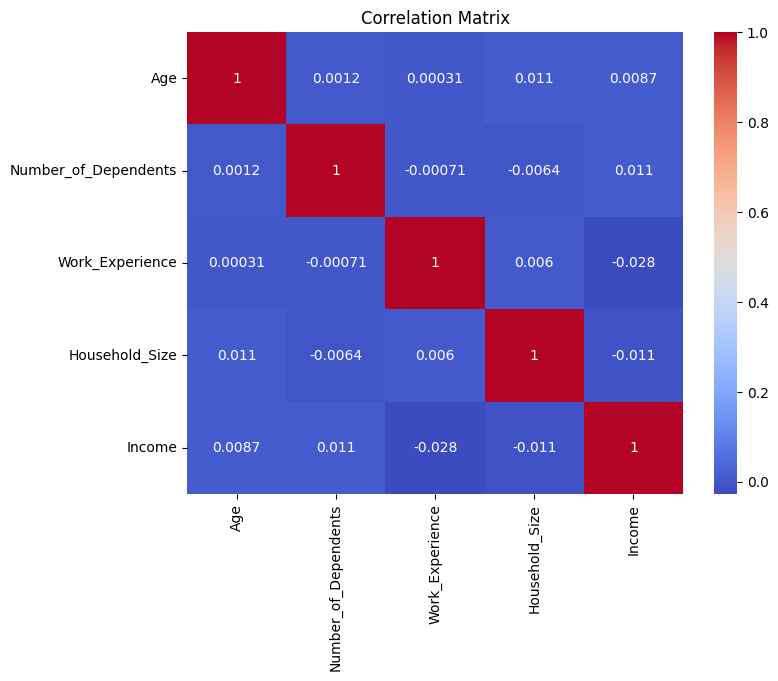

Income                  1.000000
Number_of_Dependents    0.011413
Age                     0.008739
Household_Size         -0.011356
Work_Experience        -0.027541
Name: Income, dtype: float64


In [115]:
numeric_analysis = df[numeric_cols]

corr = numeric_analysis.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

print(corr["Income"].sort_values(ascending=False))

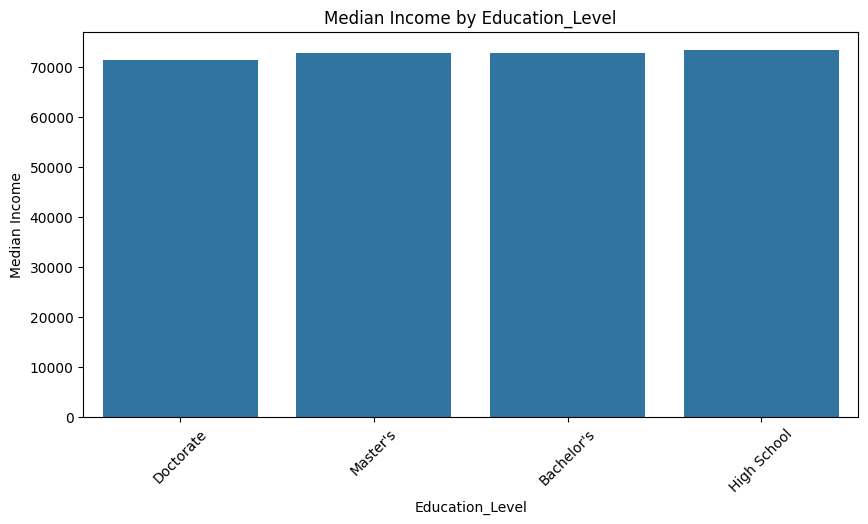

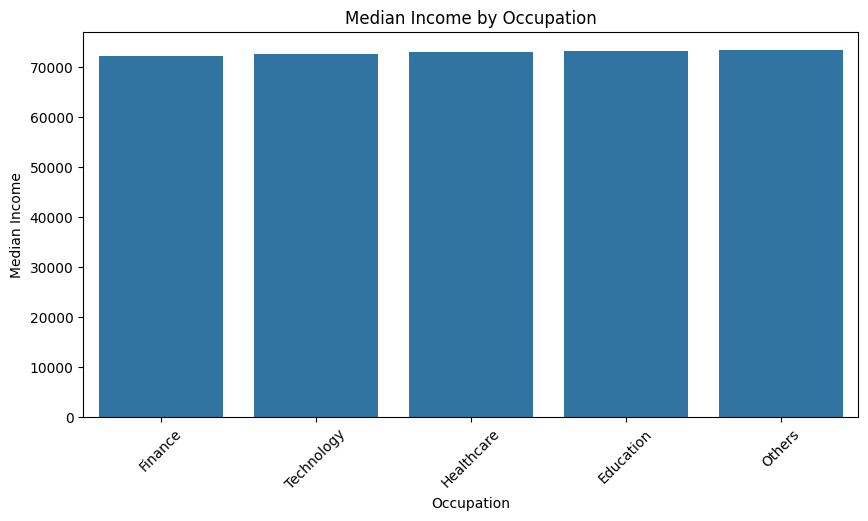

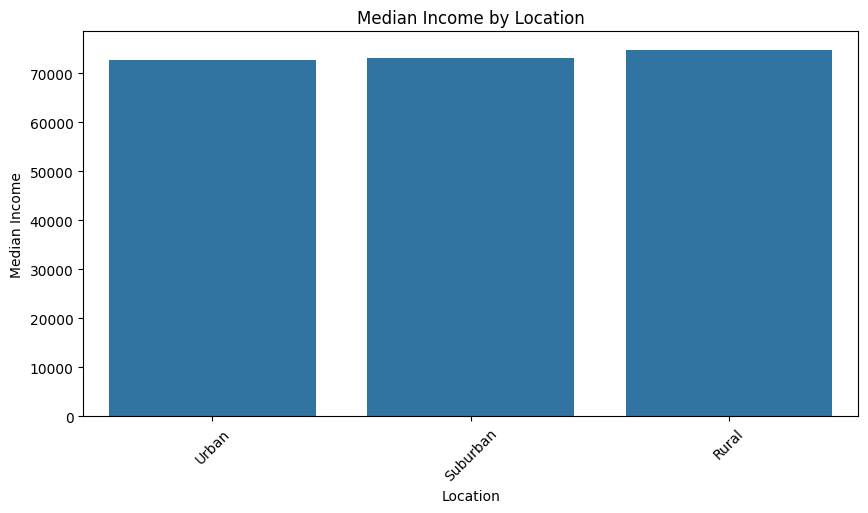

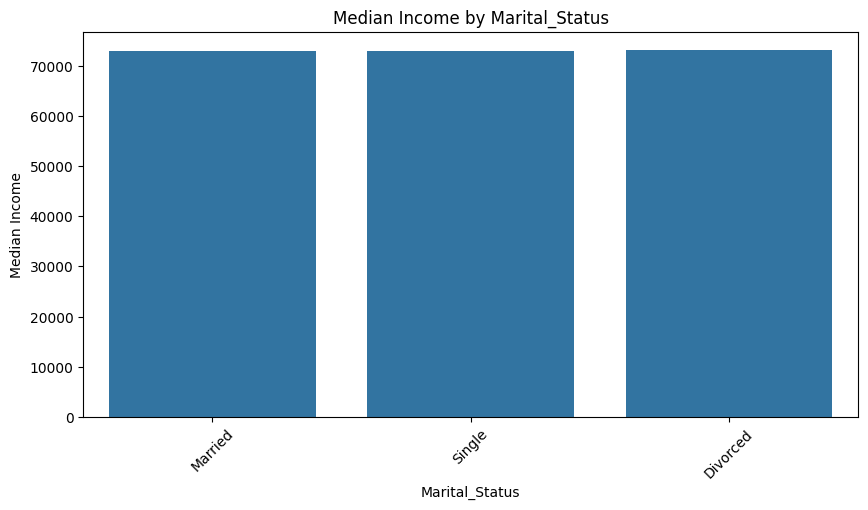

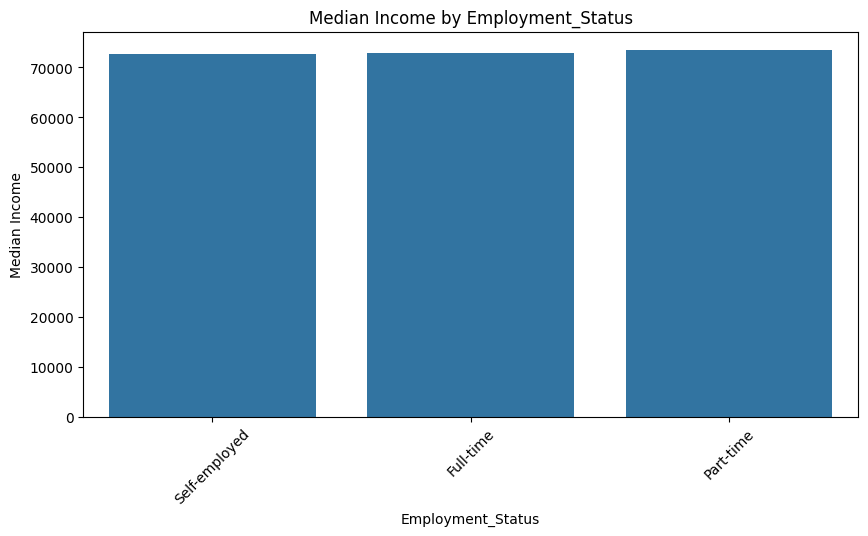

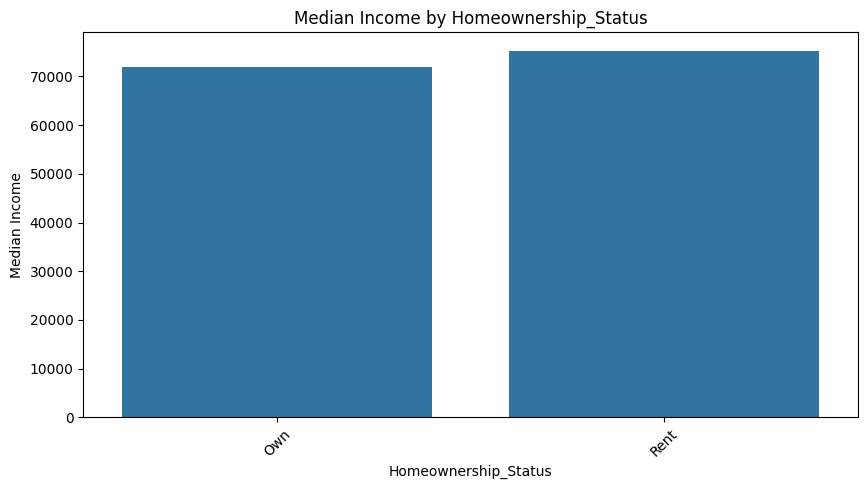

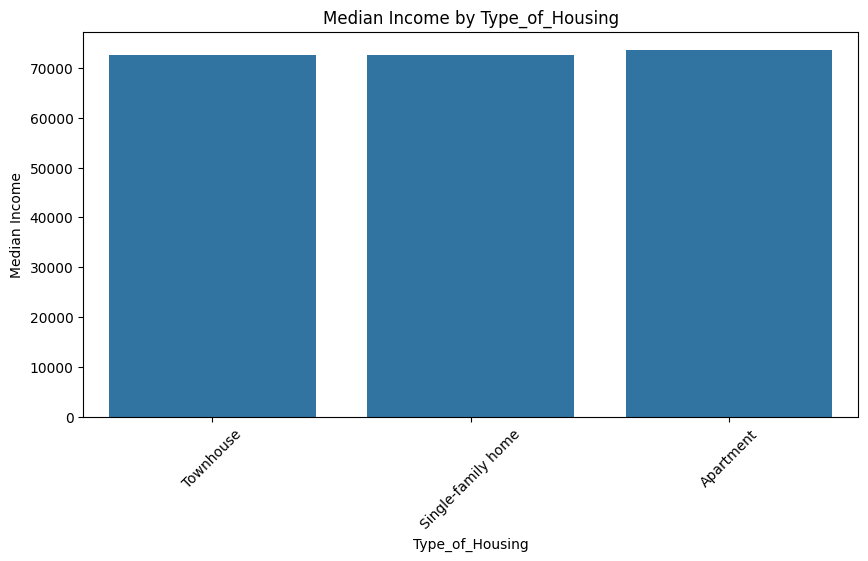

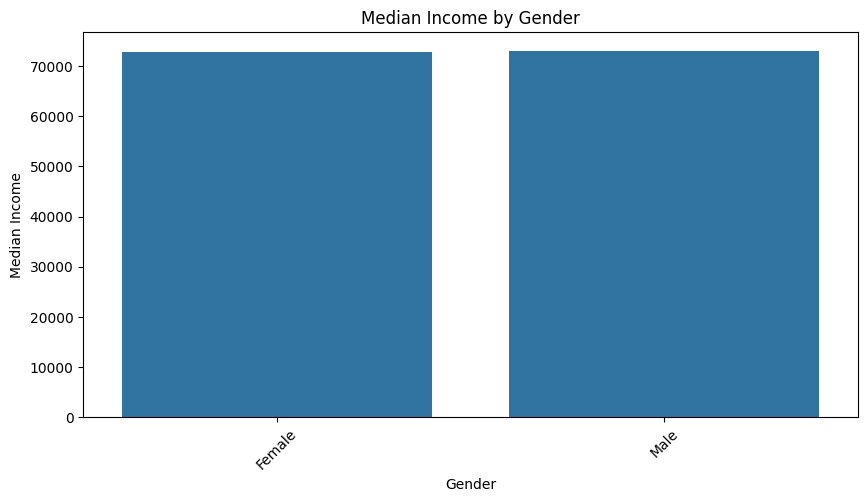

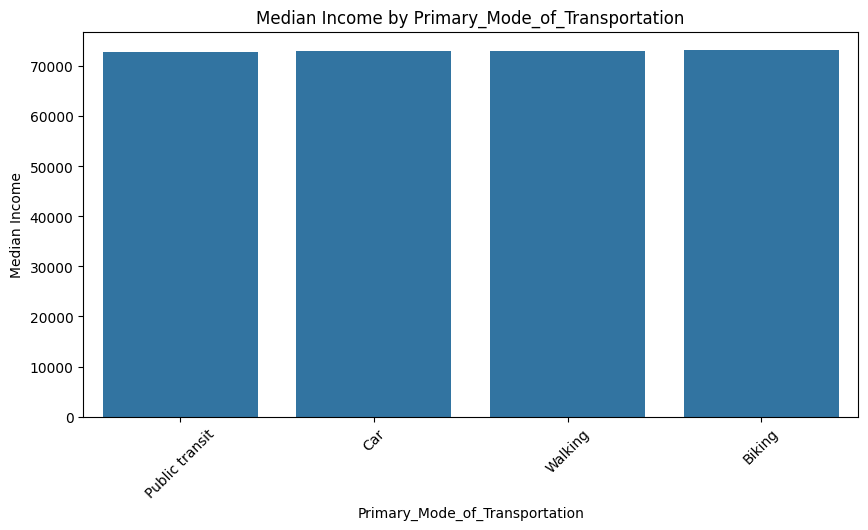

In [116]:
categorical_cols = [
    "Education_Level",
    "Occupation",
    "Location",
    "Marital_Status",
    "Employment_Status",
    "Homeownership_Status",
    "Type_of_Housing",
    "Gender",
    "Primary_Mode_of_Transportation"
]

for col in categorical_cols:
    plt.figure(figsize=(10,5))

    grouped = df.groupby(col)["Income"].median().sort_values()

    sns.barplot(
        x=grouped.index,
        y=grouped.values
    )

    plt.xticks(rotation=45)
    plt.title(f"Median Income by {col}")
    plt.ylabel("Median Income")

    plt.show()

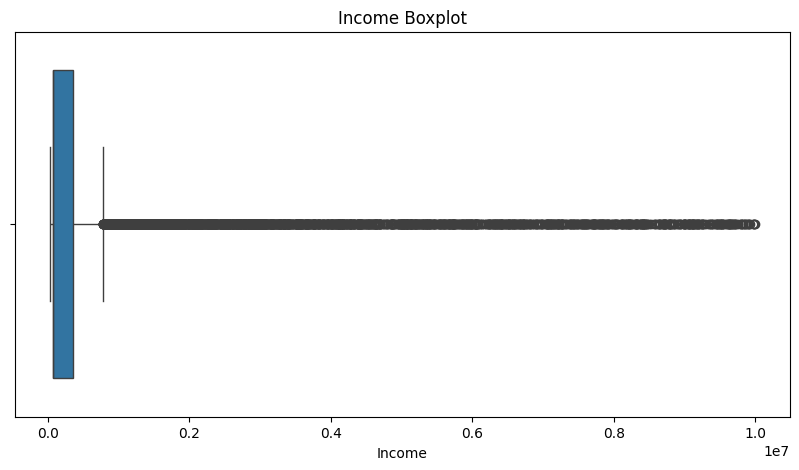

95th percentile: 5343905.449999999
99th percentile: 8836918.820000002
Max income: 9992571


In [117]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df["Income"])

plt.title("Income Boxplot")
plt.show()

# Percentiles
print("95th percentile:", df["Income"].quantile(0.95))
print("99th percentile:", df["Income"].quantile(0.99))
print("Max income:", df["Income"].max())

---

##Linear Regression

In [118]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score, mean_absolute_error, median_absolute_error, mean_squared_error


###Load data


In [119]:
column_names = [
    'Age',
    'Education_Level',
    'Occupation',
    "Number_of_Dependents",
    "Location",
    "Work_Experience",
    "Marital_Status",
    "Employment_Status",
    "Household_Size",
    "Homeownership_Status",
    "Type_of_Housing",
    "Gender",
    "Primary_Mode_of_Transportation",
    "Income"
]

df = pd.read_csv(
    "data.csv",
    names=column_names,
    na_values="?",
    skipinitialspace=True
)

# Remove duplicated header row
df = df.drop(index=0)

df.head()

,Age,Education_Level,Occupation,Number_of_Dependents,Location,Work_Experience,Marital_Status,Employment_Status,Household_Size,Homeownership_Status,Type_of_Housing,Gender,Primary_Mode_of_Transportation,Income
1,56,Master's,Technology,5,Urban,21,Married,Full-time,7,Own,Apartment,Male,Public transit,72510
2,69,High School,Finance,0,Urban,4,Single,Full-time,7,Own,Apartment,Male,Biking,75462
3,46,Bachelor's,Technology,1,Urban,1,Single,Full-time,7,Own,Single-family home,Female,Car,71748
4,32,High School,Others,2,Urban,32,Married,Full-time,1,Own,Apartment,Female,Car,74520
5,60,Bachelor's,Finance,3,Urban,15,Married,Self-employed,4,Own,Townhouse,Male,Walking,640210


###Clean numeric columns

In [120]:
numeric_cols = [
    "Age",
    "Number_of_Dependents",
    "Work_Experience",
    "Household_Size",
    "Income"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )


#Missing values
for col in df.columns:

  # Categorical columns
  if df[col].dtype == "object":
      df[col] = df[col].fillna(
          df[col].mode()[0]
      )

  # Numeric columns
  else:
      df[col] = df[col].fillna(
          df[col].median()
      )

###Features and target

In [121]:
X = df.drop("Income", axis=1)

# Log-transform target
y = np.log1p(df["Income"])

###Split dataset

In [122]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

###Preprocessing

In [123]:
numeric_features = [
    "Age",
    "Number_of_Dependents",
    "Work_Experience",
    "Household_Size"
]

categorical_features = [
    col for col in X.columns
    if col not in numeric_features
]

preprocessor = ColumnTransformer(
    transformers=[

        (
            "num",
            StandardScaler(),
            numeric_features
        ),

        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

###Model

In [124]:
model = Pipeline(steps=[

    ("preprocessor", preprocessor),

    ("regressor", LinearRegression())
])

###Train model

In [125]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age',
                                                   'Number_of_Dependents',
                                                   'Work_Experience',
                                                   'Household_Size']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Education_Level',
                                                   'Occupation', 'Location',
                                                   'Marital_Status',
                                                   'Employment_Status',
                                                   'Homeownership_Status',
                                                   'Type_of_Housing', 'Gender',
                                                   'Primary_Mode_of_Transportation'])])),
                ('regressor', LinearRegression())])

###Predict (on log scale)

In [126]:
preds_log = model.predict(X_test)

###Evaluate

In [127]:
# R² in log scale
r2_log = r2_score(y_test, preds_log)

print("R2 (log):", r2_log)

# Convert back to real scale
y_pred = np.expm1(preds_log)
y_true = np.expm1(y_test)

# Real-world metrics
mae = mean_absolute_error(y_true, y_pred)

med_ae = median_absolute_error(
    y_true,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(y_true, y_pred)
)

print("\nReal-world metrics:")
print(f"MAE: ${mae:,.2f}")
print(f"Median AE: ${med_ae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")

R2 (log): 0.03085669646217415

Real-world metrics:
MAE: $780,150.72
Median AE: $107,137.44
RMSE: $1,886,076.89
